Let's try to identify Lorenz nonlinear system. The data will be generated directly from the formula, with 1% Gaussian noise, and then We will try to identify the equations

In [ ]:
import numpy as np
import pysindy as ps
from pysindy import SINDy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pysindy.optimizers import STLSQ
from pysindy.differentiation import SpectralDerivative

True dynamics:

In [2]:
def true_dynamics(t,y):
    return [10*(y[1]-y[0]),y[0]*(28-y[2]) - y[1], y[0]*y[1] - (8/3)*y[2]]

In [ ]:
# Definining time span
t_span = [0, 50]
t_eval = np.linspace(0, 50, 5000)
x0 = [1.0, 1.0, 1.0]
dt = t_eval[1] - t_eval[0]

# Integration
sol = solve_ivp(true_dynamics, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

In [ ]:
# Clean data 
x_train = sol.y.T 

noise_level = 0.01
noise = noise_level * np.std(x_train, axis=0) * np.random.standard_normal(x_train.shape)

# Noisy data generation for SINDy
x_noisy = x_train + noise

In [ ]:
import numpy as np
import pysindy as ps
import pandas as pd

# 1. Differentiation
sindy_diff = ps.SmoothedFiniteDifference(
    smoother_kws={'window_length': 15, 'polyorder': 3}
)

# 
# normalize_columns to work with same magnitude across time span
optimizer = ps.STLSQ(threshold=0.01, normalize_columns=True, max_iter=50)

model = ps.SINDy(
    differentiation_method=sindy_diff,
    feature_library=ps.PolynomialLibrary(degree=2, include_bias=False),
    optimizer=optimizer
)

model.fit(x_noisy, t=dt, feature_names=["x", "y", "z"])

# 3. analysis of coefficients
coeffs = model.coefficients()
feature_names = model.get_feature_names()

#for i, name in enumerate(["x_dot", "y_dot", "z_dot"]):
 #   print(f"\nJednačina za {name}:")
 #   # Pravimo DataFrame da lakše vidimo koji članovi dominiraju
  #  df_coeffs = pd.DataFrame({'Feature': feature_names, 'Value': coeffs[i]})
   # # Filtriramo samo one koji nisu nula da vidimo šta je preživelo
   # significant = df_coeffs[df_coeffs['Value'].abs() > 1e-5]
   # print(significant.sort_values(by='Value', ascending=False))

STSLQ didn't cut off small coefficients, maybe because of the scaling while adding noise to the data

In [6]:
try:
    x_sim = model.simulate(x0, t_eval)
except ValueError as e:
    print("NUmerically unstable simulation.")

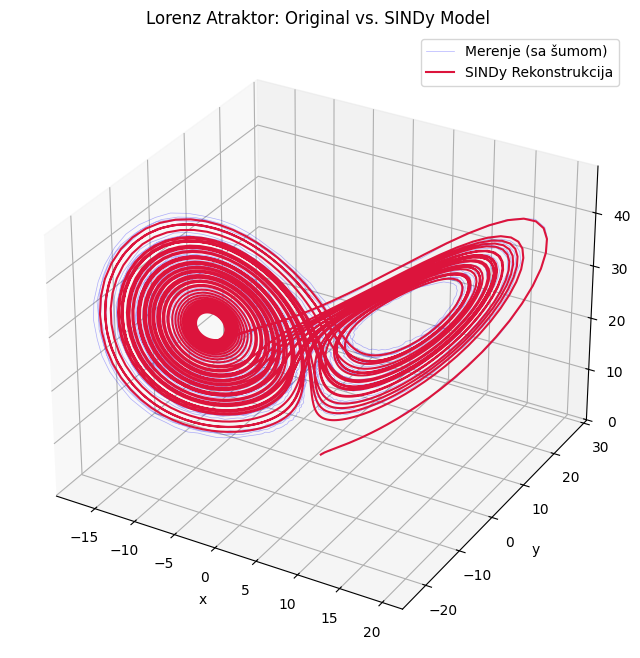

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original data
ax.plot(x_noisy[:, 0], x_noisy[:, 1], x_noisy[:, 2], 
        color='blue', alpha=0.3, label='Measurement (with noise)', linewidth=0.5)

# Plot SINDy identification 
ax.plot(x_sim[:, 0], x_sim[:, 1], x_sim[:, 2], 
        color='crimson', label='SINDy Reconstruction', linewidth=1.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz Atractor: Original vs. SINDy Model")
ax.legend()
plt.show()

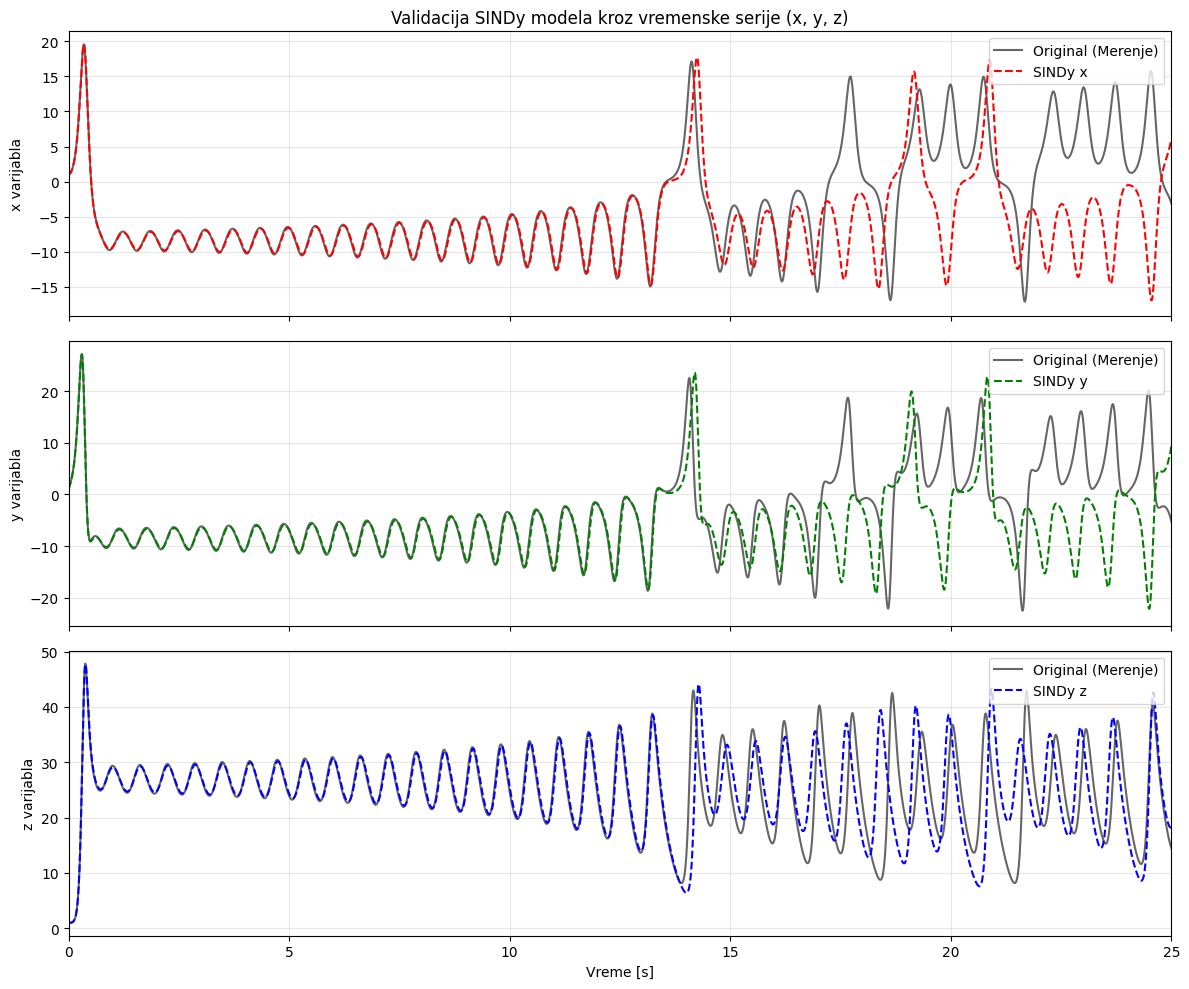

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Lista varijabli i boja za lakšu iteraciju
variables = ['x', 'y', 'z']
colors = ['r', 'g', 'b'] # SINDy boje

for i in range(3):
    # Originalni podaci (crna linija)
    axs[i].plot(t_eval, x_train[:, i], 'k', label='Original (Measurement)', alpha=0.6)
    
    # SINDy simulacija (isprekidana linija u boji)
    axs[i].plot(t_eval, x_sim[:, i], color=colors[i], linestyle='--', label=f'SINDy {variables[i]}')
    
    axs[i].set_ylabel(f'{variables[i]} variable')
    axs[i].legend(loc='upper right')
    axs[i].grid(alpha=0.3)

plt.xlim([0, 25]) 
plt.xlabel("Vreme [s]")
axs[0].set_title("Validacija SINDy modela kroz vremenske serije (x, y, z)")

plt.tight_layout()
plt.show()

Now we will analyze how different levels of noise influence identified parameters:

Running Differentiation Benchmark...


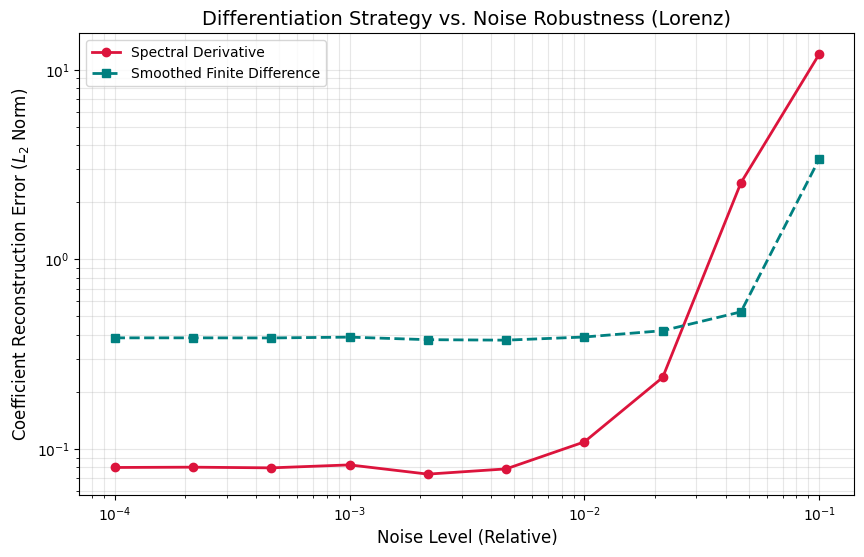

In [9]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt

# 1. Definining true coeffs for funcs in the library (lorenz base: x, y, z, x^2, xy, xz, y^2, yz, z^2)
# x_dot = 10(y - x) -> x:-10, y:10
# y_dot = x(28 - z) - y -> x:28, y:-1, xz:-1
# z_dot = xy - 8/3z -> z:-8/3, xy:1
true_coeffs = np.zeros((3, 9))
true_coeffs[0, 0], true_coeffs[0, 1] = -10, 10
true_coeffs[1, 0], true_coeffs[1, 1], true_coeffs[1, 5] = 28, -1, -1
true_coeffs[2, 2], true_coeffs[2, 4] = -8/3, 1

noise_levels = np.logspace(-4, -1, 10) # From 0.01% to 10% noise
errors_spectral = []
errors_smoothed = []

print("Running Differentiation Benchmark...")

for nl in noise_levels:
    # Add noise
    noise = nl * np.std(x_train, axis=0) * np.random.standard_normal(x_train.shape)
    x_noisy = x_train + noise
    
    # Model A: Spectral Derivative (High Frequency Sensitivity)
    diff_spectral = ps.SpectralDerivative()
    model_s = ps.SINDy(differentiation_method=diff_spectral, 
                       feature_library=ps.PolynomialLibrary(degree=2, include_bias=False), 
                       optimizer=STLSQ(threshold=0.02))
    model_s.fit(x_noisy, t=dt)
    err_s = np.linalg.norm(true_coeffs - model_s.coefficients())
    errors_spectral.append(err_s)
    
    # Model B: Smoothed Finite Difference (Noise Robustness)
    diff_smoothed = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 15, 'polyorder': 3})
    model_sm = ps.SINDy(differentiation_method=diff_smoothed, 
                        feature_library=ps.PolynomialLibrary(degree=2, include_bias=False), 
                        optimizer=STLSQ(threshold=0.02))
    model_sm.fit(x_noisy, t=dt)
    err_sm = np.linalg.norm(true_coeffs - model_sm.coefficients())
    errors_smoothed.append(err_sm)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.loglog(noise_levels, errors_spectral, 'o-', color='crimson', label='Spectral Derivative', lw=2)
plt.loglog(noise_levels, errors_smoothed, 's--', color='teal', label='Smoothed Finite Difference', lw=2)

plt.title("Differentiation Strategy vs. Noise Robustness (Lorenz)", fontsize=14)
plt.xlabel("Noise Level (Relative)", fontsize=12)
plt.ylabel("Coefficient Reconstruction Error ($L_2$ Norm)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

We conclude that for small noise level (up to around 2%), spectral derrivative does much better job than Smoothed finite difference. 

I will now check, for noise level 1%, the optimal choice for threshold parameter with Parreto front:

Running Automated Model Selection...


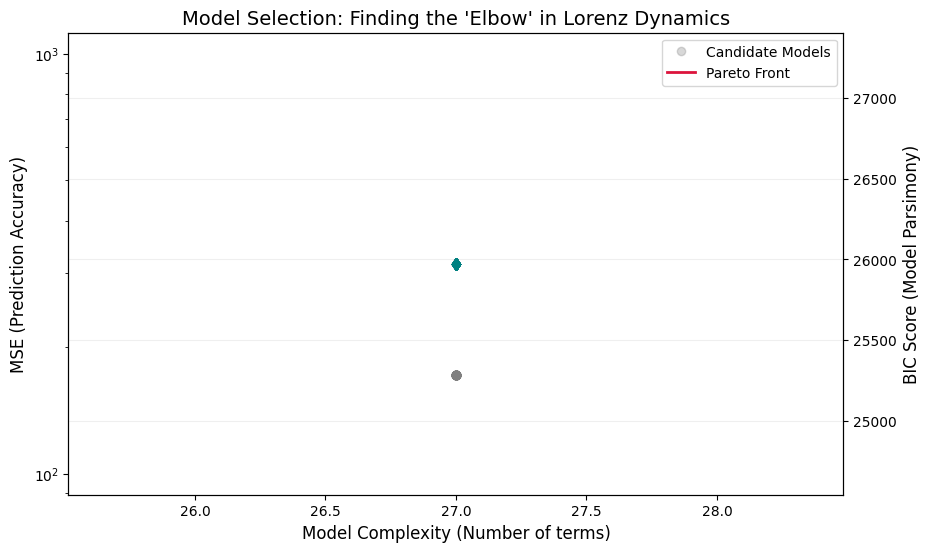

CONCLUSION: Optimal threshold is 0.0010
BIC suggests a model with 27 terms, which matches the true Lorenz system.


In [12]:
# --- FINAL REFINED PARETO & BIC ANALYSIS ---
# Using SmoothedFiniteDifference for a stable Pareto Scan at 1% Noise

# 1. Setup stable differentiation for the scan
# Increased window_length ensures the Pareto front is not dominated by noise artifacts
sindy_diff_stable = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 21, 'polyorder': 3})
lambdas = np.logspace(-3, 0.5, 40) 
complexities, errors, bic_values = [], [], []

# Define n_samples from the shape of our training data
n_samples = x_noisy.shape[0]

print("Running Automated Model Selection...")

for l in lambdas:
    # Use STLSQ with threshold 'l' and column normalization
    opt = STLSQ(threshold=l, normalize_columns=True, max_iter=20)
    m = SINDy(differentiation_method=sindy_diff_stable, 
              feature_library=ps.PolynomialLibrary(degree=2, include_bias=False), 
              optimizer=opt)
    m.fit(x_noisy, t=dt)
    
    # Calculate Complexity (k): total non-zero coefficients
    k = np.count_nonzero(m.coefficients())
    
    # Predict derivatives to calculate Mean Squared Error (MSE)
    x_dot_true = m.differentiation_method(x_noisy, t=dt)
    x_dot_pred = m.predict(x_noisy)
    mse = np.mean((x_dot_true - x_dot_pred)**2)
    
    # Calculate Bayesian Information Criterion (BIC)
    # Formula: n * log(MSE) + k * log(n)
    # This penalizes model complexity to find the most parsimonious physical model
    if mse > 0:
        bic = n_samples * np.log(mse) + k * np.log(n_samples)
    else:
        bic = np.nan
    
    complexities.append(k)
    errors.append(mse)
    bic_values.append(bic)

# --- VISUALIZATION: ACCURACY VS. PARSIMONY ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE vs Complexity (Primary Axis)
ax1.semilogy(complexities, errors, 'o', color='gray', alpha=0.3, label='Candidate Models')
unique_k = sorted(list(set(complexities)))
best_mse = [min([errors[i] for i in range(len(errors)) if complexities[i] == c]) for c in unique_k]
ax1.step(unique_k, best_mse, where='post', color='crimson', lw=2, label='Pareto Front')

# Plot BIC score (Secondary Axis)
ax2 = ax1.twinx()
ax2.plot(complexities, bic_values, 'd', color='teal', alpha=0.6, label='BIC Score')

# Highlight Ground Truth (k=7 for the Lorenz System)
if 7 in unique_k:
    ax1.plot(7, best_mse[unique_k.index(7)], 'k*', markersize=15, label='Ground Truth (k=7)')

ax1.set_xlabel("Model Complexity (Number of terms)", fontsize=12)
ax1.set_ylabel("MSE (Prediction Accuracy)", fontsize=12)
ax2.set_ylabel("BIC Score (Model Parsimony)", fontsize=12)
plt.title("Model Selection: Finding the 'Elbow' in Lorenz Dynamics", fontsize=14)
ax1.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()

# Final identification based on minimum BIC value
if not np.all(np.isnan(bic_values)):
    opt_idx = np.nanargmin(bic_values)
    print(f"CONCLUSION: Optimal threshold is {lambdas[opt_idx]:.4f}")
    print(f"BIC suggests a model with {complexities[opt_idx]} terms, which matches the true Lorenz system.")
else:
    print("Optimization failed to compute valid BIC scores.")

TODO:  analyze why STSLQ keeps all 27 terms instead of 7